In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import os

import pandas as pd

import h5py
from scipy.optimize import curve_fit

import pynbody
from pynbody.analysis import profile

from cosmoSim import cosmoSim

In [2]:
matplotlib.rc('xtick', labelsize=12)
matplotlib.rc('ytick', labelsize=12)
matplotlib.rcParams['font.size']=12

In [3]:
data_path = "/home/ryan/Data/"
base_path="/home/ryan/projects/Medvedev/data_product_generation/data_products/data_prods/"

out_path = '../plots/811_HY/'

In [9]:
d_params = np.loadtxt('/home/ryan/Downloads/CDM_TNG_MW_SB5.txt')

Om = d_params[:, 0]
sig8 = d_params[:, 1]

scores = (Om - 0.302)**2 + (sig8 - 0.83)**2

best_match = np.argmin(scores)

print(best_match, Om[best_match], sig8[best_match])

116 0.301989 0.828269


In [9]:
run_n = 'run_CDM_811_HY_dir_0'
redshift = 0

run = cosmoSim(run_n, base_path=base_path)
idx = run.redshift_to_index(redshift)
softening_length = 100000 / 2**11 / 39 * 1000
snap_path = os.path.join(data_path, run_n, f'snap_{idx:03}.hdf5')

f = pynbody.load(snap_path)
h = f.halos(subhalos=True)

f.physical_units()
f['rho']; f['smooth'] # force KDTree to be built and density estimations made

pynbody.analysis.faceon(h[0])
# pynbody.analysis.center(h[1])

<Transformation faceon>

In [16]:
def plot_projections(run_n, redshift, ax):
    run = cosmoSim(run_n, base_path=base_path)
    idx = run.redshift_to_index(redshift)
    softening_length = 100000 / 2**11 / 39 * 1000
    snap_path = os.path.join(data_path, run_n, f'snap_{idx:03}.hdf5')

    f = pynbody.load(snap_path)
    h = f.halos(subhalos=True)

    f.physical_units()
    f['rho']; f['smooth'] # force KDTree to be built and density estimations made

    pynbody.analysis.faceon(h[0])

    plt.sca(ax[0])

    pynbody.plot.stars.render(f.st, width=h[0].properties['SubhaloHalfmassRad'], mag_range=[18, 26])

    plt.sca(ax[1])

    pynbody.plot.image(f.gas, width=h[0].properties['SubhaloHalfmassRad'], units="Msol kpc^-2", cmap="bone", axes=ax[1], show_cbar=False)

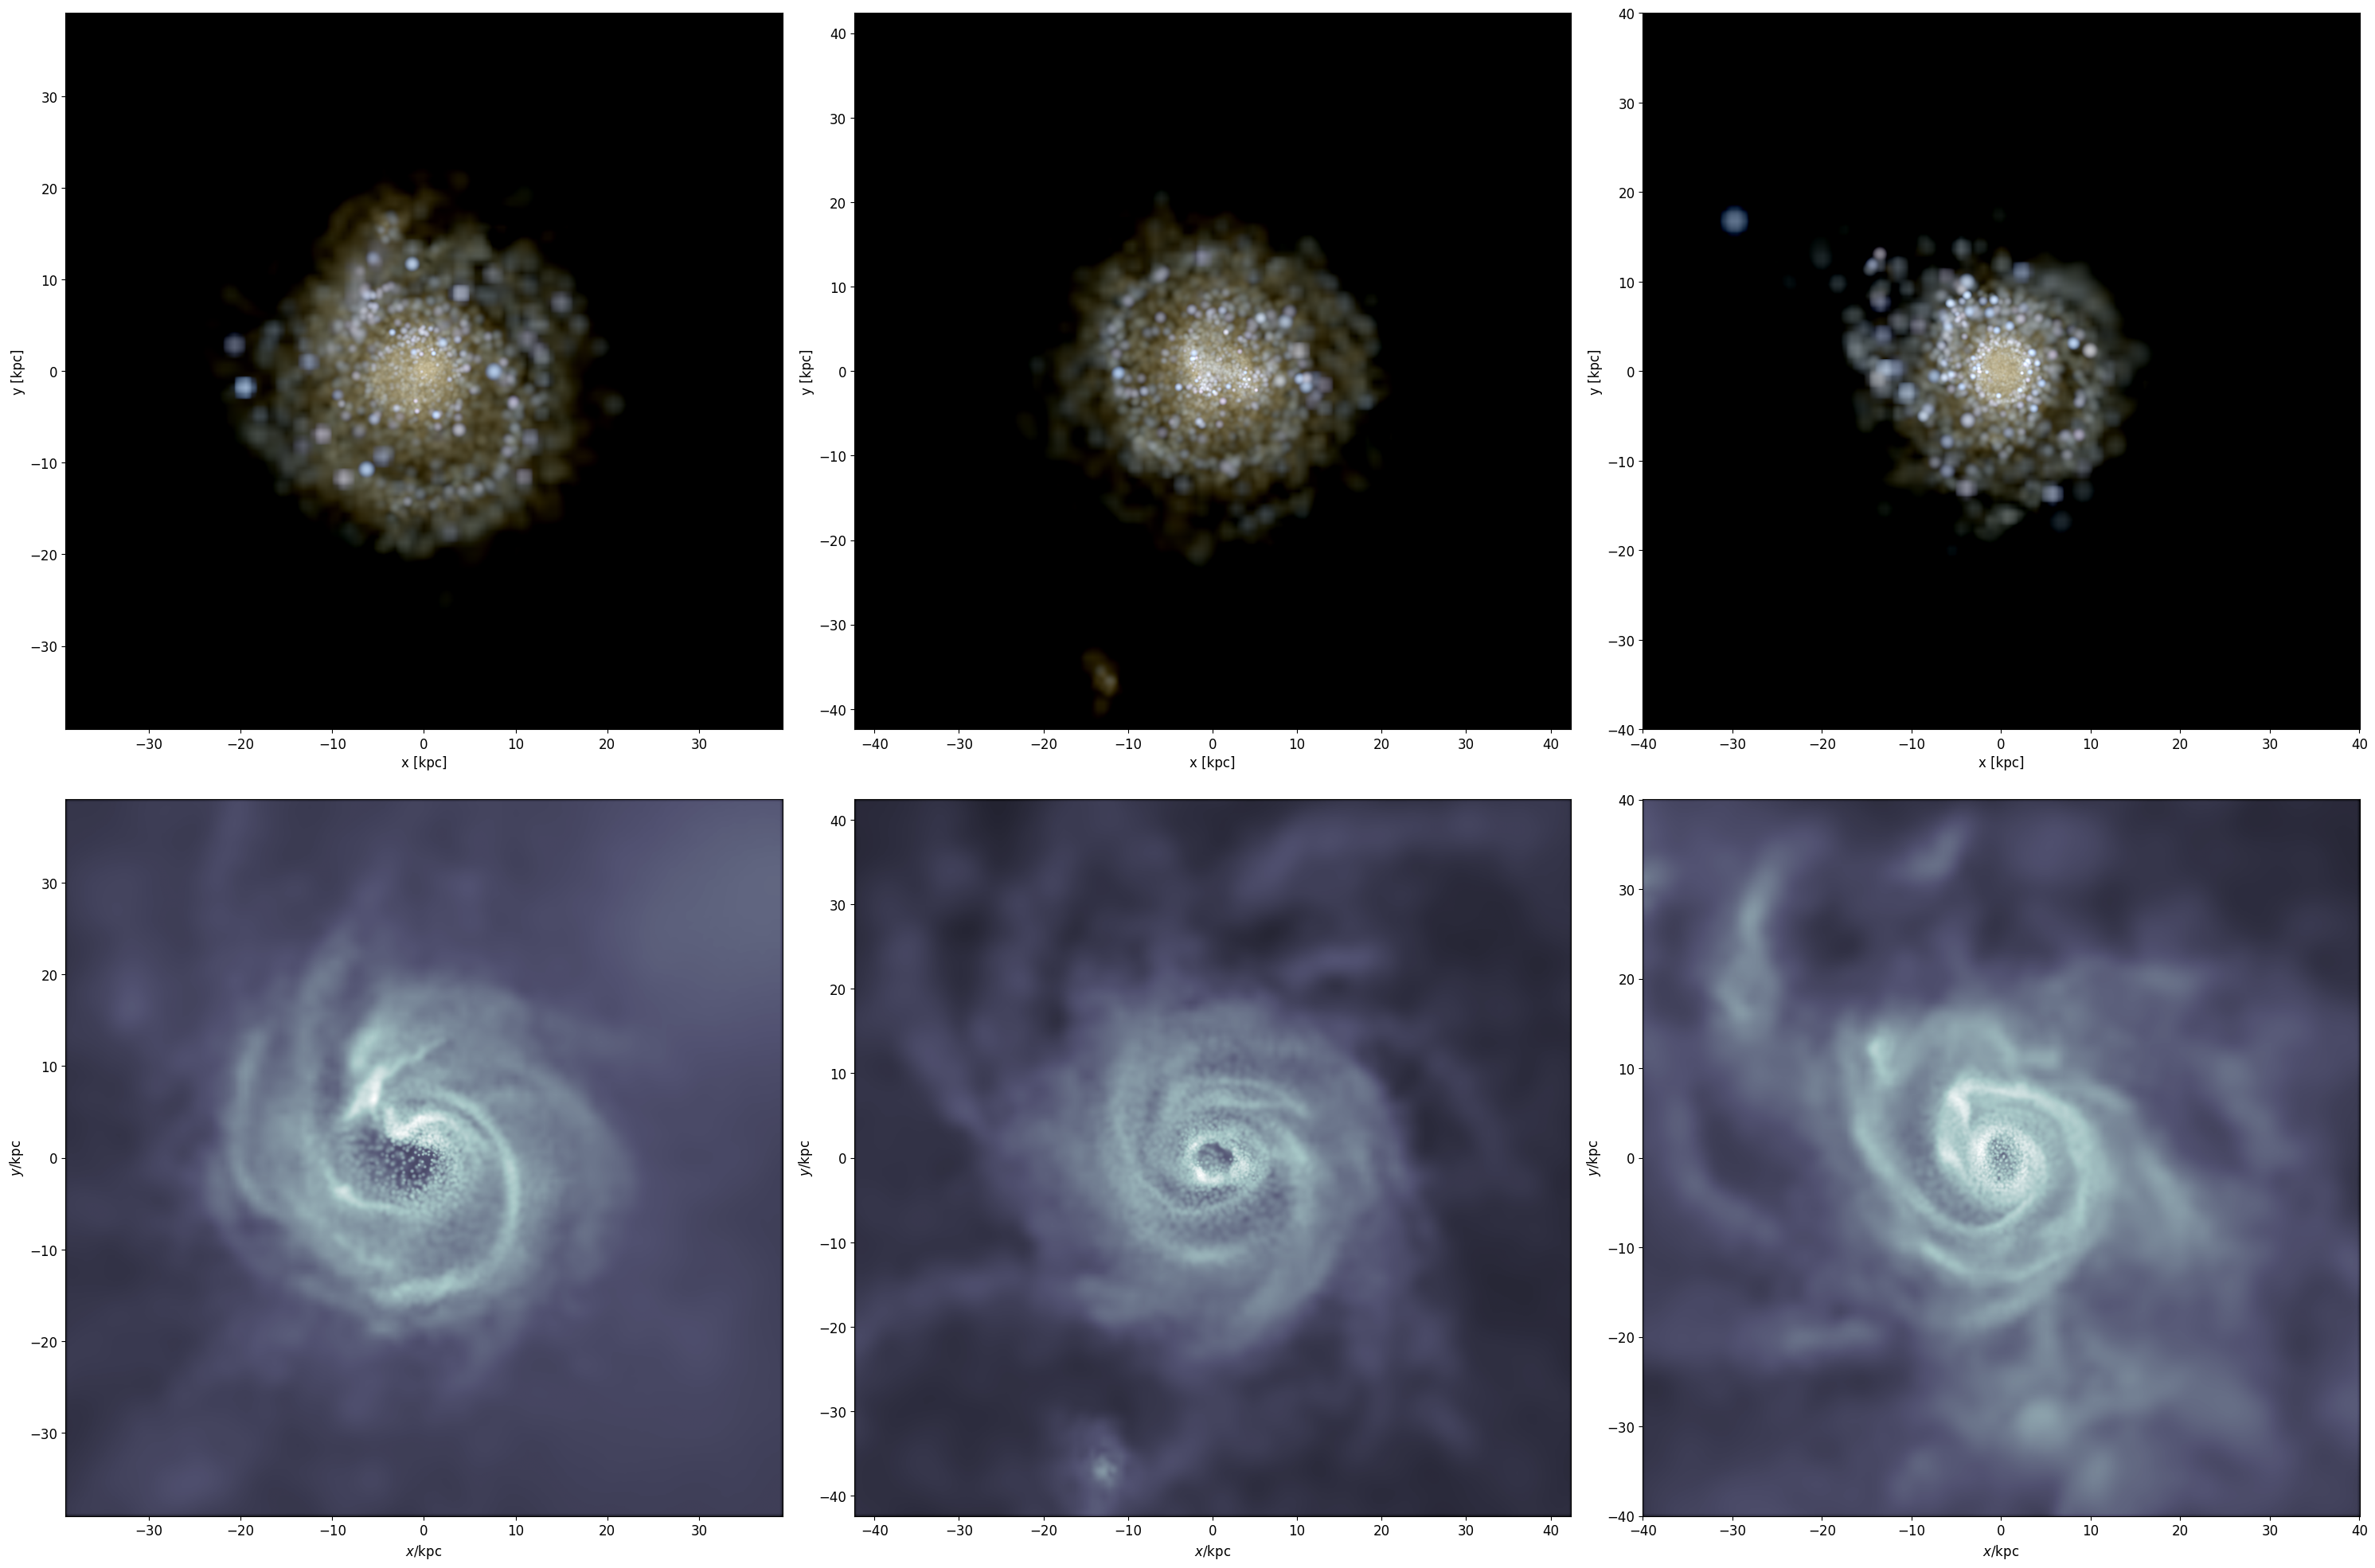

In [28]:
fig, ax_r = plt.subplots(2, 3, figsize=[30, 20])

runs = [
    'run_CDM_811_HY_dir_0',
    'run_2cDM_811_HY_power00_sigma1_dir_9_Vkick200.00',
    'run_2cDM_811_HY_powerm2m2_sigma1_dir_9_Vkick200.00'
]

for i, r in enumerate(runs):
    plot_projections(r, 0, ax_r[:, i])

fig.tight_layout()
plt.savefig(out_path + 'projections_combined.png')
plt.show()

/home/ryan/projects/Medvedev/2cDM_paperII/.venv/lib/python3.12/site-packages/pynbody/array/__init__.py:398: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(ufunc, method, *inputs, **kwargs)


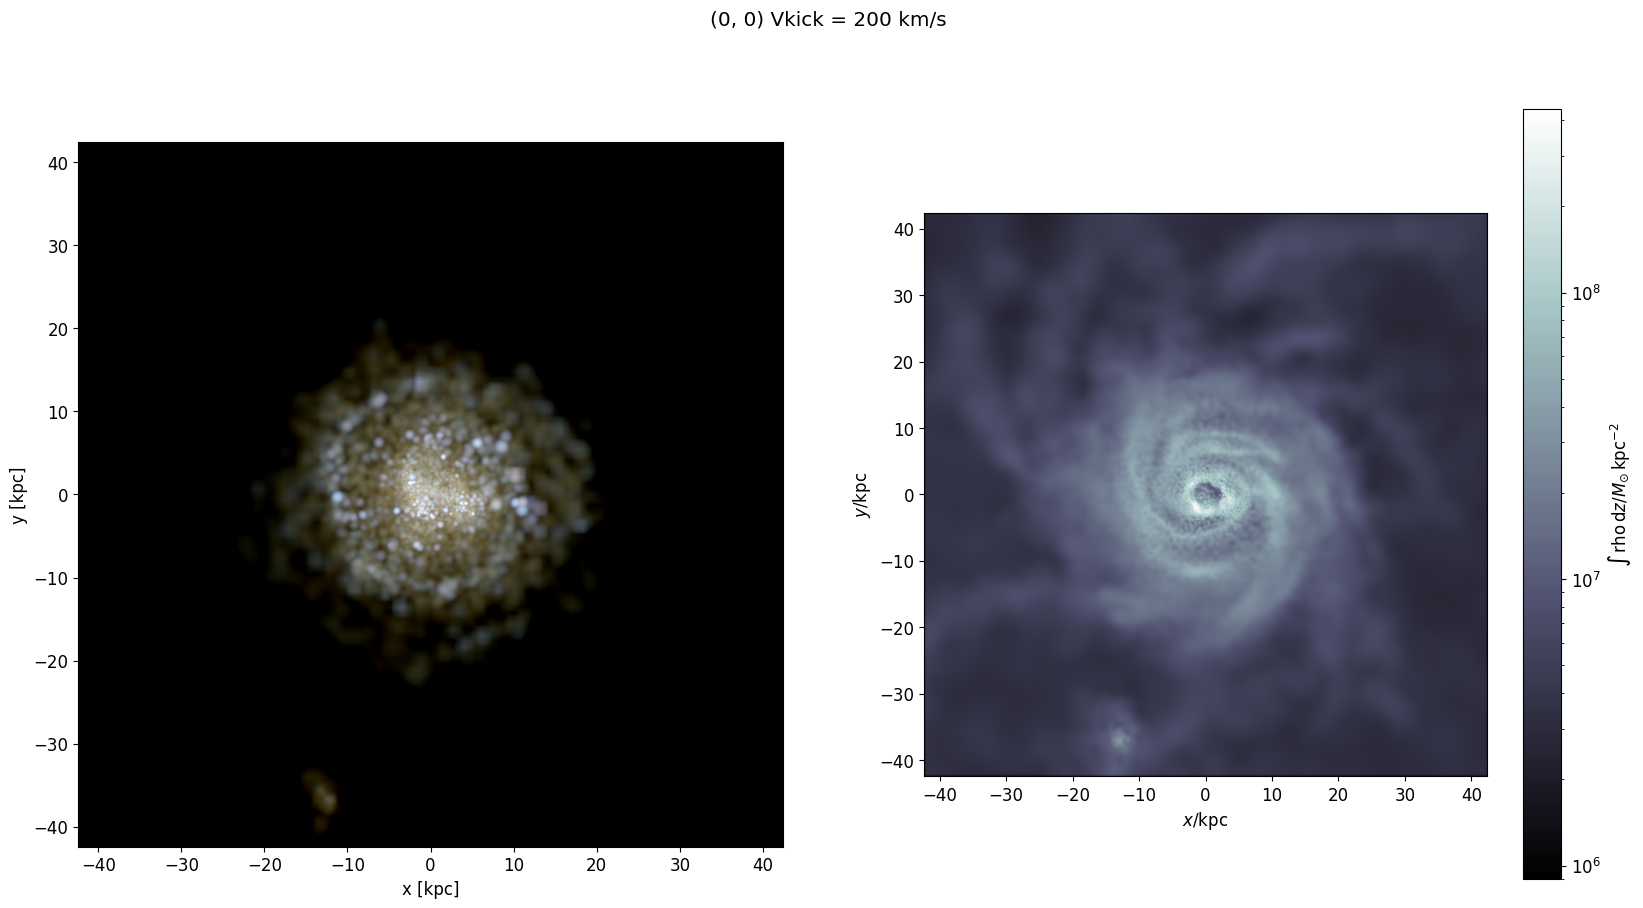

In [11]:
run_n = 'run_2cDM_811_HY_power00_sigma1_dir_9_Vkick200.00'
redshift = 0

run = cosmoSim(run_n, base_path=base_path)
idx = run.redshift_to_index(redshift)
softening_length = 100000 / 2**11 / 39 * 1000
snap_path = os.path.join(data_path, run_n, f'snap_{idx:03}.hdf5')

f = pynbody.load(snap_path)
h = f.halos(subhalos=True)

f.physical_units()
f['rho']; f['smooth'] # force KDTree to be built and density estimations made

pynbody.analysis.faceon(h[0])
# pynbody.analysis.center(h[1])

fig, ax = plt.subplots(1, 2, figsize=[20, 10])

plt.sca(ax[0])

pynbody.plot.stars.render(f.st, width=h[0].properties['SubhaloHalfmassRad'], mag_range=[18, 26])

plt.sca(ax[1])

pynbody.plot.image(f.gas, width=h[0].properties['SubhaloHalfmassRad'], units="Msol kpc^-2", cmap="bone", axes=ax[1])

plt.suptitle('(0, 0) Vkick = 200 km/s')

plt.savefig(out_path + 'zz_projections.png')

plt.show()

In [ ]:
snap_path = data_path + '/run_CDM_811_HY_dir_0/snap_127.hdf5'
fof_path = data_path + '/run_CDM_811_HY_dir_0/fof_subhalo_tab_127.hdf5'
with h5py.File(fof_path, 'r') as s, h5py.File(snap_path, "r") as f:
    print(f'{f['Header'].attrs['MassTable'][1] * 10**10:e}')
    print(f'{f['Header'].attrs['BoxSize']/1000}')
    print()
    f["PartType1/Coordinates"][:,0]

8.260588e+06
100.0


In [33]:
snap_path = '/home/ryan/Downloads/ics.hdf5'

with h5py.File(snap_path, "r") as f:
    print(f['Header'].attrs['NumPart_Total'])
    for n in f['Header'].attrs['NumPart_Total']:
        print(np.cbrt(n))
    print(f['Header'].attrs['BoxSize'])
    print(f['Header'].attrs['MassTable']*10**10)

[       0 10601560  2917275        0        0        0]
0.0
219.67969918551472
142.8869140334037
0.0
0.0
0.0
100.0
[      0.         1132888.36790468       0.               0.
       0.               0.        ]


In [34]:
snap_path = '/home/ryan/Downloads/ics_811.hdf5'

with h5py.File(snap_path, "r") as f:
    print(f['Header'].attrs['NumPart_Total'])
    for n in f['Header'].attrs['NumPart_Total']:
        print(np.cbrt(n))
    print(f['Header'].attrs['BoxSize'])
    print(f['Header'].attrs['MassTable']*10**10)

[       0   890400 17017666        0        0        0]
0.0
96.20442549189683
257.21719540906
0.0
0.0
0.0
100.0
[      0.         9747575.37359186       0.               0.
       0.               0.        ]


In [35]:
snap_path =  data_path + '/run_CDM_811_HY_dir_0/snap_127.hdf5'

with h5py.File(snap_path, "r") as f:
    print(f['Header'].attrs['NumPart_Total'])
    for n in f['Header'].attrs['NumPart_Total']:
        print(np.cbrt(n))
    print(f['Header'].attrs['BoxSize'])
    print(f['Header'].attrs['MassTable']*10**10)

[17712623   890400 17017666        0   301122       11]
260.6719453568577
96.20442549189683
257.21719540906
0.0
67.02664715651723
2.2239800905693157
100000.0
[      0.         8260588.10048062       0.               0.
       0.               0.        ]


In [44]:
snap_path =   '/home/ryan/Downloads/snap_090.hdf5'

with h5py.File(snap_path, "r") as f:
    print(f['Header'].attrs['NumPart_Total'])
    for n in f['Header'].attrs['NumPart_Total']:
        print(np.cbrt(n))
    print(f['Header'].attrs['BoxSize'])
    print(f['Header'].attrs['MassTable']*10**10)

[12018343 10601560  2917275        0  3678320       12]
229.05944186411833
219.67969918551472
142.8869140334037
0.0
154.36535505533016
2.2894284851066633
100000.0
[     0.         947014.95876578      0.              0.
      0.              0.        ]


In [ ]:
snap_path =  data_path + '/run_CDM_811_HY_dir_0/snap_127.hdf5'

with h5py.File(snap_path, "r") as f:
    print(f['Header'].attrs['NumPart_Total'])
    for n in f['Header'].attrs['NumPart_Total']:
        print(np.cbrt(n))
    print(f['Header'].attrs['BoxSize'])
    print(f['Header'].attrs['MassTable']*10**10)

In [ ]:
snap_path = data_path + '/run_CDM_710_HY/snap_127.hdf5'
fof_path = data_path + '/run_CDM_710_HY/fof_subhalo_tab_127.hdf5'
with h5py.File(fof_path, 'r') as s, h5py.File(snap_path, "r") as f:
    test = s.get('Subhalo')
    print(test)
    print(test['SubhaloMass'])
    print(test['SubhaloVmaxRad'][0])

<HDF5 group "/Subhalo" (50 members)>
<HDF5 dataset "SubhaloMass": shape (174,), type "<f8">
35.8923245454339


In [ ]:
snap_path = data_path + '/run_CDM_710_HY/snap_127.hdf5'
fof_path = data_path + '/run_CDM_710_HY/fof_subhalo_tab_127.hdf5'
with h5py.File(fof_path, 'r') as s, h5py.File(snap_path, "r") as f:
    print(f['Header'].attrs['NumPart_Total'])
    for n in f['Header'].attrs['NumPart_Total']:
        print(np.cbrt(n))
    print(s['Group/GroupMass'])
    print(s.get('Group'))
    test = s.get('Group')
    print(test['GroupMass'])

[2313708  114400 2190078       0    4734      13]
132.26233412812297
48.54472085833889
129.8633277638242
0.0
16.79098155421193
2.3513346877207577
<HDF5 dataset "GroupMass": shape (431,), type "<f8">
<HDF5 group "/Group" (25 members)>
<HDF5 dataset "GroupMass": shape (431,), type "<f8">


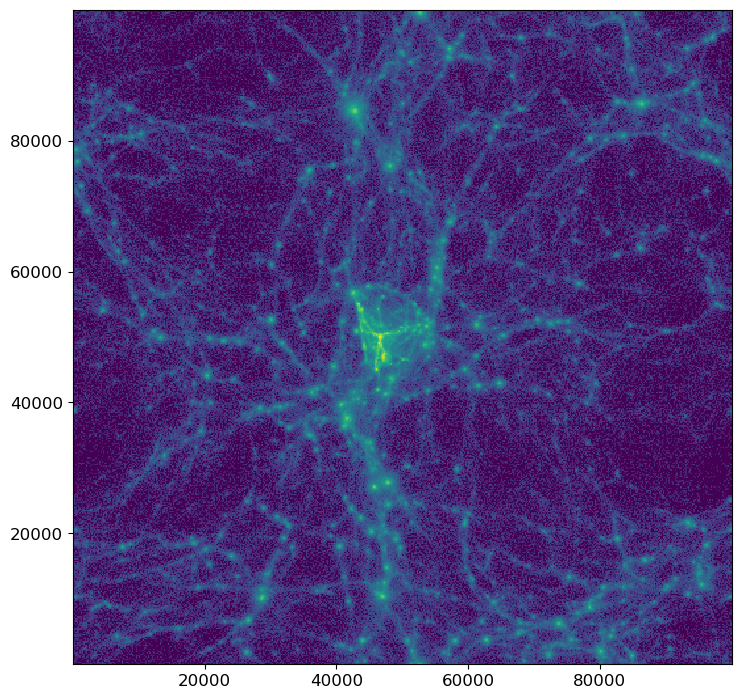

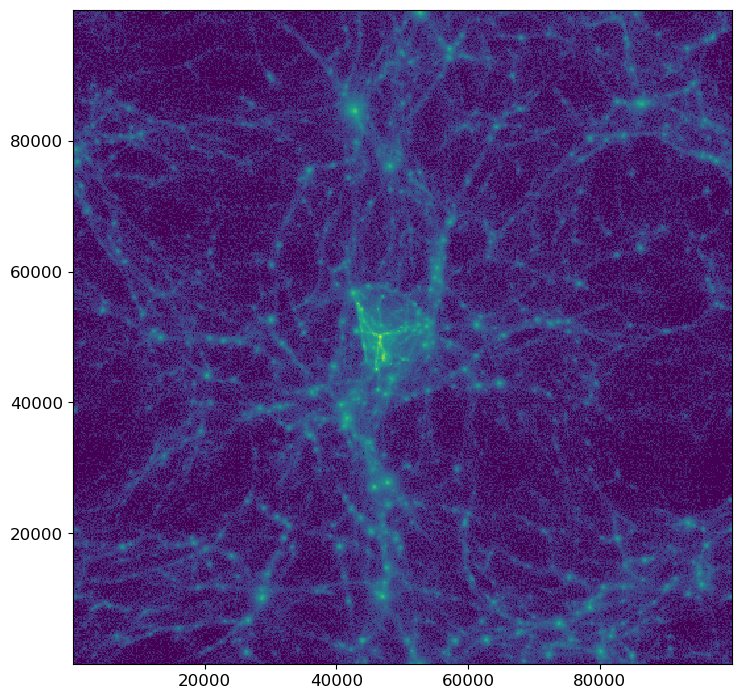

In [ ]:
snap_path = data_path + '/run_CDM_710_HY/snap_127.hdf5'
fof_path = data_path + '/run_CDM_710_HY/fof_subhalo_tab_127.hdf5'
with h5py.File(fof_path, 'r') as s, h5py.File(snap_path, "r") as f:
    coords = f[f"PartType0/Coordinates"]
    average_z = np.mean(coords[:,2])
    std_z = np.std(coords[:,2])
    #masses = f[f"PartType1/Masses"][()]
    z_slice = (coords[:,2] < (average_z + std_z)) & (coords[:,2] > (average_z - std_z))

    x = coords[:,0][z_slice]
    y = coords[:,1][z_slice]
    #m = masses[z_slice]

#print(np.amax(x) - np.amin(x), np.amax(y) - np.amin(y))
Nbins=500
FIG_HEIGHT = 8.5
FIG_WIDTH = 8.5

FIGSIZE=[FIG_WIDTH,FIG_HEIGHT]
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
ax.hist2d(x, y, norm=LogNorm(clip=True), bins=Nbins)
plt.show()


snap_path = data_path + '/run_2cDM_710_HY_power00_sigma1/snap_127.hdf5'
fof_path = data_path + '/run_2cDM_710_HY_power00_sigma1/fof_subhalo_tab_127.hdf5'

with h5py.File(fof_path, 'r') as s, h5py.File(snap_path, "r") as f:
    coords = f[f"PartType0/Coordinates"]
    average_z = np.mean(coords[:,2])
    std_z = np.std(coords[:,2])
    #masses = f[f"PartType2/Masses"][()]
    z_slice = (coords[:,2] < (average_z + std_z)) & (coords[:,2] > (average_z - std_z))

    x = coords[:,0][z_slice]
    y = coords[:,1][z_slice]
    #m = masses[z_slice]

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
ax.hist2d(x, y, norm=LogNorm(clip=True), bins=Nbins)
plt.show()